In [ ]:
import xwrf
import xarray as xr
import numpy as np
import glob
import pickle
from wrf import latlon_coords, ll_to_xy
from netCDF4 import Dataset
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

Plot instantaneous temperature time series – observed vs. modelled (Default, LCZ, WSF-MB, and Geoscape experiments) – at BoM stations - Figure S5

In [ ]:
#load WRF and station data - extraction code at the bottom
with open("/g/data/gb02/mf9078/WRF_Results-10-20Jan_xy_wtime_Dec.pkl", "rb") as f:
    wrf_stations = pickle.load(f)

with open("/g/data/gb02/mf9078/AWS_Temperature_Data_10-20Jan.pkl", "rb") as f:
    df_all_stations = pickle.load(f)

df_urban_aws = df_all_stations[df_all_stations['Station'].isin(['SYDNEY AIRPORT AMO', 'SYDNEY (OBSERVATORY HILL)', 'BANKSTOWN AIRPORT AWS', 'CANTERBURY RACECOURSE AWS', 'SYDNEY OLYMPIC PARK AWS (ARCHERY CENTRE)'])]
df_urban_aws = df_urban_aws.reset_index(drop=True)
df_urban_aws['Station'] = df_urban_aws['Station'].replace({'SYDNEY AIRPORT AMO': 'SA', 'SYDNEY (OBSERVATORY HILL)': 'OH', 'BANKSTOWN AIRPORT AWS': 'BA', 'CANTERBURY RACECOURSE AWS': 'CR', 'SYDNEY OLYMPIC PARK AWS (ARCHERY CENTRE)': 'OP'})
df_urban_aws

,Time,Temperature,Maximum Temperature,Minimum Temperature,Station,Station Number,Latitude,Longitude
0,2017-01-10 00:00:00,22.6,22.8,22.0,SA,66037,-33.9465,151.1731
1,2017-01-10 01:00:00,22.1,22.3,21.9,SA,66037,-33.9465,151.1731
2,2017-01-10 02:00:00,22.0,22.3,21.9,SA,66037,-33.9465,151.1731
3,2017-01-10 03:00:00,22.9,23.2,22.7,SA,66037,-33.9465,151.1731
4,2017-01-10 04:00:00,23.2,23.4,23.0,SA,66037,-33.9465,151.1731
...,...,...,...,...,...,...,...,...
1200,2017-01-19 20:00:00,22.1,22.1,22.0,OP,66212,-33.8338,151.0718
1201,2017-01-19 21:00:00,21.9,21.9,21.9,OP,66212,-33.8338,151.0718
1202,2017-01-19 22:00:00,21.4,21.6,21.4,OP,66212,-33.8338,151.0718
1203,2017-01-19 23:00:00,20.8,20.9,20.8,OP,66212,-33.8338,151.0718


  agg_filter: a filter function, which takes a (m, n, 3) float array and a dpi value, and returns a (m, n, 3) array and two offsets from the bottom left corner of the image
  alpha: float or None
  animated: bool
  antialiased: bool
  backgroundcolor: :mpltype:`color`
  bbox: dict with properties for `.patches.FancyBboxPatch`
  clip_box: `~matplotlib.transforms.BboxBase` or None
  clip_on: bool
  clip_path: Patch or (Path, Transform) or None
  color or c: :mpltype:`color`
  figure: `~matplotlib.figure.Figure` or `~matplotlib.figure.SubFigure`
  fontfamily or family or fontname: {FONTNAME, 'serif', 'sans-serif', 'cursive', 'fantasy', 'monospace'}
  fontproperties or font or font_properties: `.font_manager.FontProperties` or `str` or `pathlib.Path`
  fontsize or size: float or {'xx-small', 'x-small', 'small', 'medium', 'large', 'x-large', 'xx-large'}
  fontstretch or stretch: {a numeric value in range 0-1000, 'ultra-condensed', 'extra-condensed', 'condensed', 'semi-condensed', 'normal', 

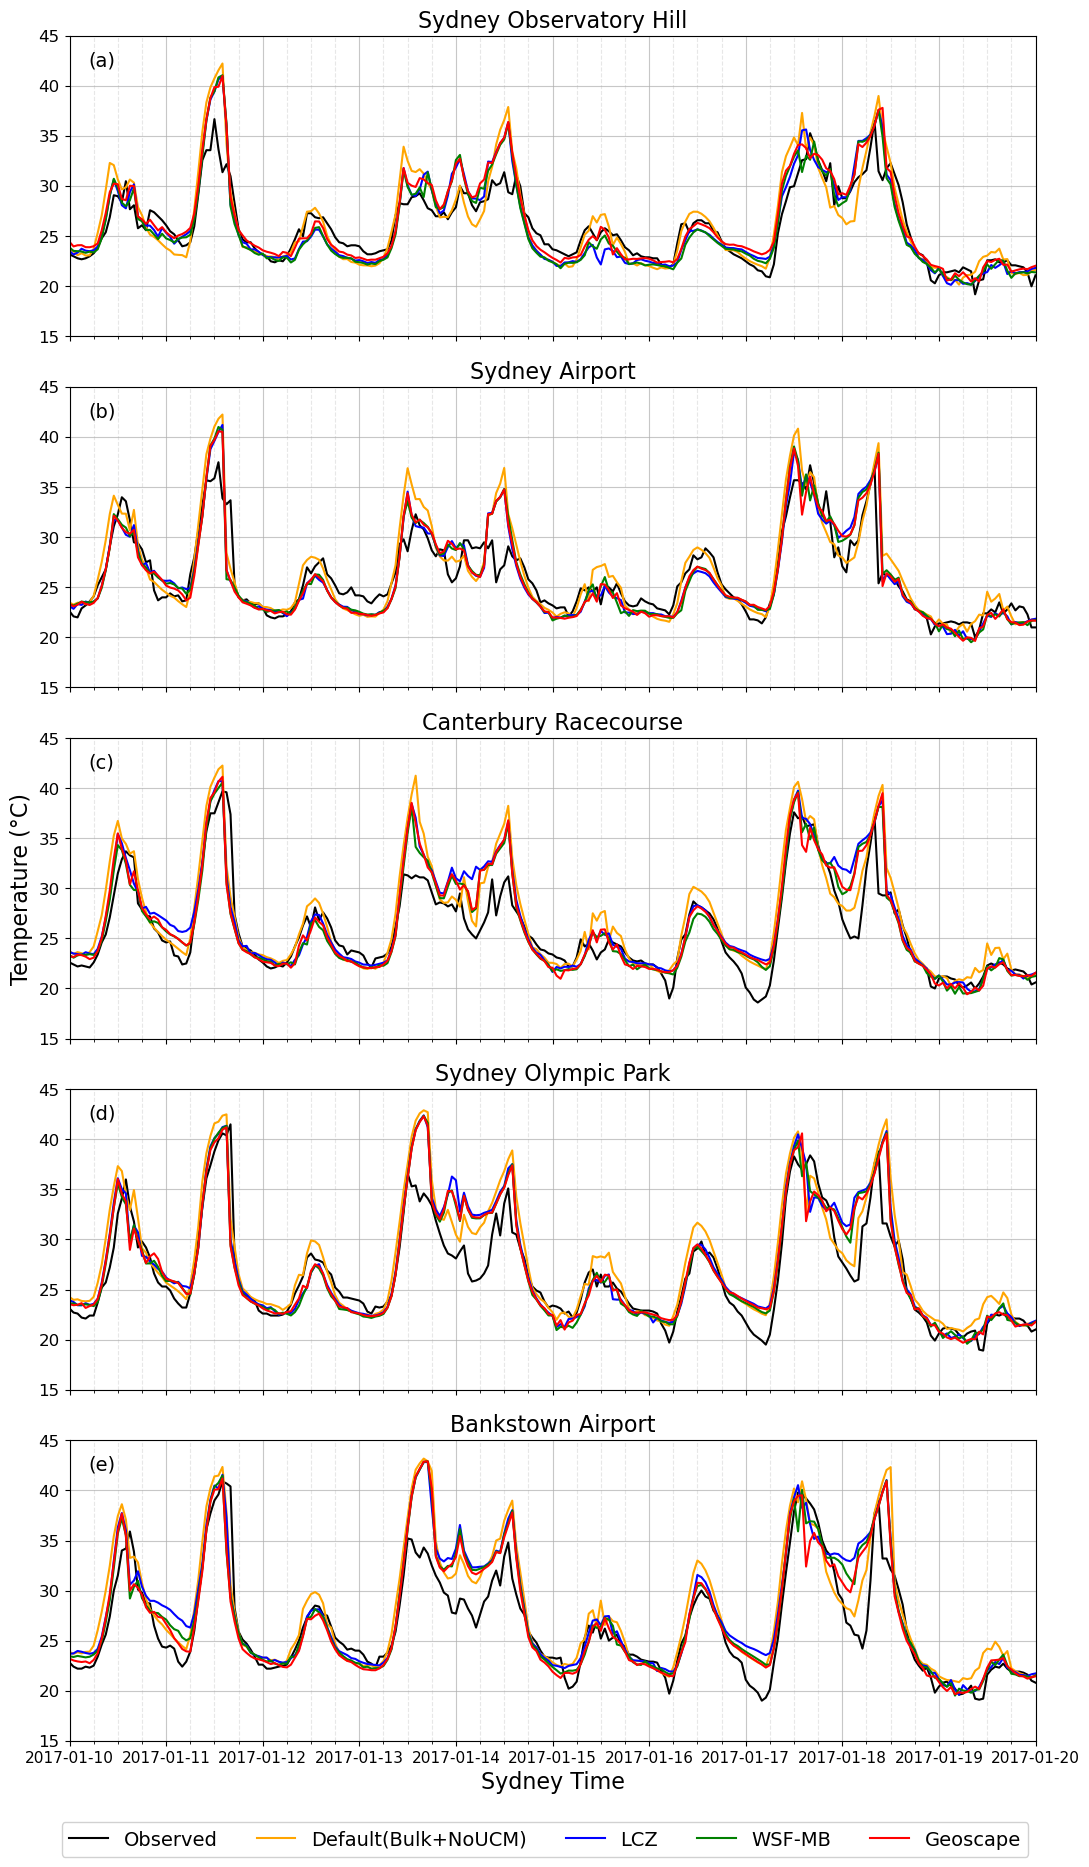

In [ ]:
#plot

# Define station names mapping
station_names = {
    'SA': 'Sydney Airport',
    'OH': 'Sydney Observatory Hill',
    'BA': 'Bankstown Airport',
    'CR': 'Canterbury Racecourse',
    'OP': 'Sydney Olympic Park'
}

# Define urban stations
urbanaws = ['OH', 'SA', 'CR', 'OP', 'BA']

# Define line colors
line_colors = {
    'Default(Bulk+NoUCM)': 'orange',
    'LCZ': 'blue',
    'WSF-MB': 'green', 
    'Geoscape': 'red'
}

# WRF experiments (excluding 'time')
experiments = ['Default(Bulk+NoUCM)', 'LCZ', 'WSF-MB', 'Geoscape']

# Create figure with 5 subplots
fig, axes = plt.subplots(5, 1, figsize=(11, 18), sharex=True)
fig.subplots_adjust(hspace=0.3)

# Subplot labels
subplot_labels = ['(a)', '(b)', '(c)', '(d)', '(e)']

# Store handles and labels for legend
handles_list = []
labels_list = []

# Loop through each urban station
for idx, station in enumerate(urbanaws):
    ax = axes[idx]
    
    # Plot observations
    station_obs = df_urban_aws[df_urban_aws['Station'] == station]
    obs_line, = ax.plot(station_obs['Time'], station_obs['Temperature'], 
            color='black', label='Observed', linewidth=1.5, linestyle='-')
    if idx == 0:
        handles_list.append(obs_line)
        labels_list.append('Observed')

    # Plot WRF experiments
    for experiment in experiments:
        line, = ax.plot(wrf_stations['time'], wrf_stations[experiment][station], 
                color=line_colors[experiment], label=experiment, linewidth=1.5)
        if idx == 0:  # Collect handles and labels from first subplot
            handles_list.append(line)
            labels_list.append(experiment)
       
    # Set title and labels
    ax.set_title(station_names[station], fontsize=16)
    ax.set_ylim(15, 45)
    # Only add ylabel to middle subplot
    if idx == 2:
        ax.set_ylabel('Temperature (°C)', fontsize=16)
    ax.grid(True, alpha=0.3)
    
    # Add subplot label
    ax.text(0.02, 0.95, subplot_labels[idx], transform=ax.transAxes,
            fontsize=14, va='top', ha='left')
    
    ax.tick_params(axis='y', which='major', labelsize=12)

axes[-1].tick_params(axis='x', which='major', labelsize=11)

# Set x-axis formatting for the bottom subplot
axes[-1].set_xlabel('Sydney Time', fontsize=16)

# Set ticks
axes[-1].xaxis.set_major_locator(mdates.DayLocator())
axes[-1].xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))

# Grid lines
for i in list(range(5)):
    axes[i].grid(True, which='minor', linestyle='--', alpha=0.3)  # 6-hourly
    axes[i].grid(True, which='major', linestyle='-', alpha=0.7)   # daily

# Set x-axis limits
start_date = datetime(2017, 1, 10)
end_date = datetime(2017, 1, 20)
axes[-1].set_xlim(start_date, end_date)

# Rotate x-axis labels for better readability
plt.setp(axes[-1].xaxis.get_majorticklabels())

# Add horizontal legend at the bottom
fig.legend(handles_list, labels_list, loc='lower center', ncol=5, 
           fontsize=14, framealpha=0.9, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.subplots_adjust(bottom=0.03)  # Make room for the legend
plt.savefig("S5-Temperature_Timeseries_BoM.png", dpi=300)
plt.show()

Extract WRF data

In [ ]:
#WRF grids corresponding to the stations locations
# File path and domain bounds
file_path = "/g/data/fy29/mf9078/run_WRF/etamodified/output/0out/animation/wrfout_d02_2017-01-19_08:00:00"

#13 stations
awsfile = ['HD01D_Data_066037_9999999910708353.nc','HD01D_Data_066059_9999999910708353.nc','HD01D_Data_066062_9999999910723658.nc','HD01D_Data_066137_9999999910708353.nc','HD01D_Data_066161_9999999910708353.nc','HD01D_Data_066194_9999999910708353.nc','HD01D_Data_066212_9999999910708353.nc','HD01D_Data_067105_9999999910708353.nc','HD01D_Data_067108_9999999910708353.nc','HD01D_Data_067113_9999999910708353.nc','HD01D_Data_067119_9999999910708403.nc','HD01D_Data_068192_9999999910708403.nc','HD01D_Data_068257_9999999910708403.nc']
awslat = [-33.9465,-33.6908,-33.8607,-33.9176,-33.9925,-33.9057,-33.8338,-33.6004,-33.8969,-33.7195,-33.851,-34.039,-34.0615]
awslon = [151.1731,151.2253,151.205,150.9837,150.9489,151.1134,151.0718,150.7761,150.7281,150.6783,150.8567,150.689,150.7735]
awsnm_full = ['SYDNEY AIRPORT AMO','TERREY HILLS AWS','SYDNEY (OBSERVATORY HILL)','BANKSTOWN AIRPORT AWS','HOLSWORTHY AERODROME AWS','CANTERBURY RACECOURSE AWS','SYDNEY OLYMPIC PARK AWS (ARCHERY CENTRE)','RICHMOND RAAF','BADGERYS CREEK AWS','PENRITH LAKES AWS','HORSLEY PARK EQUESTRIAN CENTRE AWS','CAMDEN AIRPORT AWS','CAMPBELLTOWN (MOUNT ANNAN)']
awsnm = ['SA','TH','OH','BA','HA','CR','OP','RR','BC','PL','HP','CA','CT']

# Load data
ds = xr.open_dataset(file_path)

#x_y = ll_to_xy(Dataset(file_path), -33.9465, 151.1731, stagger=None, as_int=True) #for 1 point
x_y = ll_to_xy(Dataset(file_path), awslat, awslon, stagger=None, as_int=True)
x_y

In [ ]:
#extract T2 at station locations for all cases

awslat = [-33.9465,-33.6908,-33.8607,-33.9176,-33.9925,-33.9057,-33.8338,-33.6004,-33.8969,-33.7195,-33.851,-34.039,-34.0615]
awslon = [151.1731,151.2253,151.205,150.9837,150.9489,151.1134,151.0718,150.7761,150.7281,150.6783,150.8567,150.689,150.7735]
awsnm_full = ['SYDNEY AIRPORT AMO','TERREY HILLS AWS','SYDNEY (OBSERVATORY HILL)','BANKSTOWN AIRPORT AWS','HOLSWORTHY AERODROME AWS','CANTERBURY RACECOURSE AWS','SYDNEY OLYMPIC PARK AWS (ARCHERY CENTRE)','RICHMOND RAAF','BADGERYS CREEK AWS','PENRITH LAKES AWS','HORSLEY PARK EQUESTRIAN CENTRE AWS','CAMDEN AIRPORT AWS','CAMPBELLTOWN (MOUNT ANNAN)']
awsnm = ['SA','TH','OH','BA','HA','CR','OP','RR','BC','PL','HP','CA','CT']

scenario = ['Default(Bulk+NoUCM)', 'LCZ', 'WSF-MB', 'Geoscape']
wrf_files = [
    "/g/data/fy29/mf9078/run_WRF/etamodified/output/0out/animation/wrfout_d02_2017-01*",
    "/g/data/fy29/mf9078/run_WRF/etamodified/output/1out/animation/wrfout_d02_2017-01*",
    "/g/data/fy29/mf9078/run_WRF/etamodified/output/3out/animation/wrfout_d02_2017-01*", 
    "/g/data/fy29/mf9078/run_WRF/etamodified/output/4out/animation/wrfout_d02_2017-01*"   
]


wrf_stations = {}
for sc in scenario:
    wrf_stations[sc] = {}

for j in range(len(wrf_files)):

    files = sorted(glob.glob(wrf_files[j]))
    if j == 0: #any set of files
        ds = xr.open_mfdataset(files, parallel=True, concat_dim="Time", combine="nested").xwrf.postprocess()
        sydney_time = ds["Time"] + np.timedelta64(10, "h")  # Convert UTC to Sydney time AEST
        wrf_stations['time'] = sydney_time

    # Initialize keys with empty lists
    temp = {}
    for name in awsnm:
        temp[name] = []

    for file in files:
        ds = xr.open_dataset(file)

        for i in range(len(awsnm)):
            temp[awsnm[i]].append(ds['T2'].isel(south_north=x_y[1][i], west_east=x_y[0][i]).item() - 273.15)

    wrf_stations[scenario[j]]=temp

with open("/g/data/gb02/mf9078/WRF_Results-10-20Jan_xy_wtime_Feb.pkl", "wb") as f:
    pickle.dump(wrf_stations, f)